In [ ]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import query_library as qlib




In [2]:
def get_ranges(x, nsigma = 2.5):
    median = np.nanmedian(x)
    sigma = np.nanstd(x)
    return median -nsigma * sigma, median +nsigma * sigma

In [11]:

coadd = qlib.query_coadd_photometry(keep_cmodel = True, keep_extendedness = True)
print("coadd loaded")
truth = qlib.query_truth_table(columns = "all")
df = coadd.merge(truth, on = "objectId", how = "inner")

Features loaded
coadd loaded


In [30]:
#in the other truth catalog i'm only querying sources with a match in the object Table
query = """SELECT Z, [magabs_lsst-i_total], is_agn_ctn, is_agn, is_optical_type2
           FROM Truth
           WHERE RA > 149.31 AND RA < 150.81
           AND  DEC > 1.45 AND DEC < 3.01"""
temp_truth = qlib.query_agile(query)


# 3.5 $\leq z \leq$ 5.5  AGN in AGILE

Numbers from truth catalog and object catalog

In [158]:
z_threshold = 3.5

truth_is_highz = temp_truth["is_agn"] & (temp_truth["Z"] >= z_threshold)
truth_ctn_agn = truth_is_highz  & temp_truth["is_agn_ctn"]
truth_type1 = truth_is_highz & ~temp_truth["is_optical_type2"]


is_highz = df["is_agn"] & (df["Z"] >= z_threshold)
ctn_agn = is_highz  & df["is_agn_ctn"]
type1 = is_highz & ~df["is_optical_type2"]

print(f"N Compton thin AGN at z > 3.5 in Truth: {np.sum(truth_ctn_agn)} \n Of which Type1 : {np.sum(truth_type1)}")

print(f"N Compton thin AGN at z > 3.5 in Object: {np.sum(ctn_agn)} \n Of which Type1 : {np.sum(type1)}")

N Compton thin AGN at z > 3.5 in Truth: 3455 
 Of which Type1 : 41
N Compton thin AGN at z > 3.5 in Object: 691 
 Of which Type1 : 23


In [237]:
#fig, ax = plt.subplots()
#ax.scatter(temp_truth["Z"][truth_ctn_agn], temp_truth["magabs_lsst-i_total"][truth_ctn_agn], s =5, 
#           facecolor= "none", edgecolor = "salmon", label = "Truth CTN")
#ax.scatter(temp_truth["Z"][truth_type1], temp_truth["magabs_lsst-i_total"][truth_type1], s =30,
#           facecolor= "none", edgecolor = "b", label = "Truth Type1")
#ax.scatter(df["Z"][ctn_agn], df["magabs_lsst-i_total"][ctn_agn], s =10, c="r", label = "Object CTN")
#ax.scatter(df["Z"][type1], df["magabs_lsst-i_total"][type1], s =30, c = "b", label = "Object Type1")
#ax.set_xlabel("Z")
#ax.set_ylabel("i abs mag")
#ax.legend()

# Simple quality cuts

In [222]:
#No flags in any of lsst bands
bands = ["u", "g", "r", "i", "z", "y"]
good = np.logical_and.reduce([df[f"{band}_psfFlux_flag"]==0 for band in bands])

#Extendedness measured properly in the reference band:
good_extendedness = (
          ((df["refBand"] == "i") & (df["i_extendedness_flag"] == 0)) |
          ((df["refBand"] == "g") & (df["g_extendedness_flag"] == 0)) |
          ((df["refBand"] == "r") & (df["r_extendedness_flag"] == 0)) |
          ((df["refBand"] == "z") & (df["z_extendedness_flag"] == 0)) |
          ((df["refBand"] == "u") & (df["u_extendedness_flag"] == 0)) |
          ((df["refBand"] == "y") & (df["y_extendedness_flag"] == 0)))

good = good & good_extendedness
print(f"""N Compton thin AGN at z > 3.5 in Object after basic quality cuts: {np.sum(ctn_agn & good )}
N of which are Type1 : {np.sum(type1 & good)}""")

N Compton thin AGN at z > 3.5 in Object after basic quality cuts: 653
N of which are Type1 : 23


In [160]:
#Morphology
point_like = df["refExtendedness"]==0
print(f"""N good quality AGN z > 3.5 with poin-like morpfology: {np.sum(ctn_agn & good  & point_like)}
N of which are Type1 : {np.sum(type1 & good & point_like)}""")


N good quality AGN z > 3.5 with poin-like morpfology: 154
N of which are Type1 : 9


# SEDs

In [75]:
wavs = [3751.2, 4740.66, 6172.34, 7500.97, 8678.9, 9711.82]
flux_cols = [f"{band}_psfFlux" for band in bands]
err_cols = [f"{band}_psfFluxErr" for band in bands]

In [111]:
highz_agn = df[type1 & good & point_like].reset_index(drop=True)

In [112]:
truth_fluxes_cols = [f"lsst-{band}_total" for band in "ugrizy"]

/tmp/ipykernel_957726/1658138042.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 100000)


Text(0, 0.5, '$S_{\\nu}$ [nanoJy]')

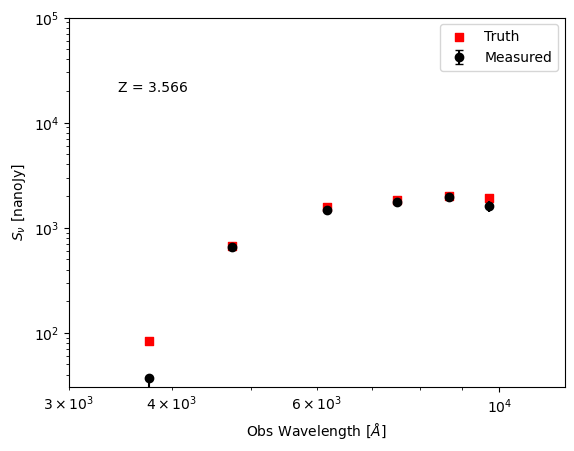

In [139]:
index = 7
flux = highz_agn.loc[index, flux_cols].to_numpy(dtype=float)
err = highz_agn.loc[index, err_cols].to_numpy(dtype=float)
is_upper_limit = err > flux
fig, ax = plt.subplots()
ax.errorbar(wavs,flux, err, ls = "none", marker = "o", c ="k",
            uplims = is_upper_limit, label = "Measured")
ax.scatter(wavs, highz_agn.loc[index, truth_fluxes_cols]*1000, c ="r", marker ="s", label = "Truth")
ax.set_xscale("log")
ax.set_yscale("log")
ax.annotate(f'Z = {np.round(highz_agn.loc[index,"Z"],3)}', (0.1, 0.8), xycoords = "axes fraction")
ax.legend()
ax.set_ylim(0, 100000)
ax.set_xlim(3000, 12000)
ax.set_xlabel(r"Obs Wavelength [$\AA$]")
ax.set_ylabel(r"$S_{\nu}$ [nanoJy]")

# Croom+ color selection
We are neglecting brightness cut on i band


In [210]:
def high_z_cut_1(data):
    a = data["u"] > 20.6
    b = data["u-g"] > 1.5
    c = data["g-r"] < 1.2
    d = data["r-i"] < 0.3 
    e = data["i-z"]> -1
    f = data["g-r"] > 0.44*data["u-g"]-0.76
    return a & b & c & d & e & f

def high_z_cut_2(data):
    b = (data["u-g"]>1.5) | (data["u"]>20.6)
    c=  data["g-r"] > 0.7
    d = (data["g-r"]>2.8) | (data["r-i"] < 0.44*data["g-r"]-0.558)
    e = (data["i-z"] > 0.25) & (data["i-z"] > -1)
    return b & c & d & e

def high_z_cut_3(data):
    a = data["u"]>21.5
    b = data["g"]>21.0
    c=  data["r-i"] > 0.6
    d=  data["i-z"] > -1
    e = data["i-z"] > 0.52 * data["r-i"] -0.762
    return a & b & c & d & e

def is_croom_highz_agn(data):
    return high_z_cut_1(data) | high_z_cut_2(data) | high_z_cut_3(data) 


def generate_croom_mock(nsample = 100000):
    data = pd.DataFrame()
    data["u"] = 22*np.ones(nsample)
    data["g"] = 22*np.ones(nsample)
    data["u-g"] = np.random.uniform(low = -3, high = 3, size = nsample)
    data["g-r"] = np.random.uniform(low = -3, high = 3, size = nsample)
    data["r-i"] = np.random.uniform(low = -3, high = 3, size = nsample)
    data["i-z"] = np.random.uniform(low = -3, high = 3, size = nsample)
    select = is_croom_highz_agn(data)
    data = data.drop(columns = ["u", "g"])
    return data[select]


In [144]:
def get_colors(fluxes):
    return -2.5*np.log10(fluxes[:, :-1]/fluxes[:, 1:])

def get_magnitudes(fluxes):
    return -2.5 * np.log10(fluxes * 1e-9 / 3631)

In [149]:
colors = get_colors(highz_agn[flux_cols].to_numpy())
colors = pd.DataFrame(colors, columns = [f"{band1}-{band2}" for band1, band2 in zip(bands[:-1], bands[1:])])
magnitudes = get_magnitudes(highz_agn[flux_cols].to_numpy())
magnitudes = pd.DataFrame(magnitudes, columns = [band for band in bands])
data = pd.concat([colors, magnitudes], axis =1)

/tmp/ipykernel_957726/1480854622.py:2: RuntimeWarning: invalid value encountered in log10
  return -2.5*np.log10(fluxes[:, :-1]/fluxes[:, 1:])
/tmp/ipykernel_957726/1480854622.py:5: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(fluxes * 1e-9 / 3631)


In [155]:
is_croom_highz = is_croom_highz_agn(data)
print(f"{is_croom_highz.sum()} out of {len(is_croom_highz)} are selected as high-z AGN")


6 out of 9 are selected as high-z AGN


# Some color color plots with poin-like sources

/tmp/ipykernel_957726/1480854622.py:2: RuntimeWarning: invalid value encountered in log10
  return -2.5*np.log10(fluxes[:, :-1]/fluxes[:, 1:])


Text(0, 0.5, 'r-i')

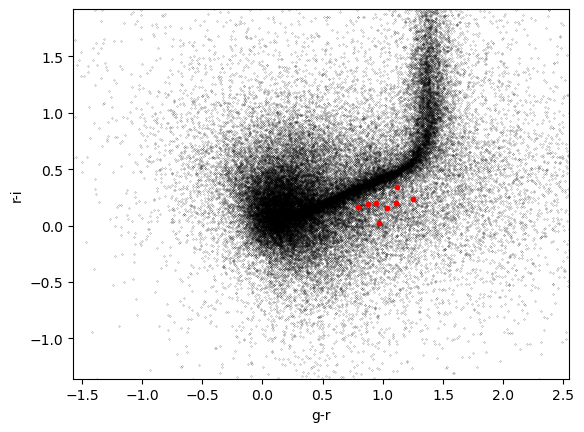

In [228]:
color1 = 1
color2 = 2

all_colors = get_colors(df[point_like & good][flux_cols].to_numpy())

resample = False
croom_locus = False
if resample:
    nsamples = False
    fluxes = highz_agn[flux_cols].to_numpy()
    err_fluxes = highz_agn[err_cols].to_numpy()
    new_fluxes = np.random.normal(loc=fluxes[None, :, :], scale=err_fluxes[None, :, :], size=(nsamples, *fluxes.shape))
    new_fluxes = np.clip(new_fluxes, 1, None)
    new_colors = new_colors = -2.5 * np.log10(new_fluxes[:, :, :-1] / new_fluxes[:, :, 1:])

fig, ax = plt.subplots()
ax.scatter(all_colors[:, color1],all_colors[:, color2], c ="k", s = 0.02)

if croom_locus:
    croom_sel = generate_croom_mock(nsample = 10000000)
    ax.scatter(croom_sel.iloc[:, color1], croom_sel.iloc[:, color2], c ="green", s =5)


if resample:
    ax.scatter(new_colors[:,:, color1],new_colors[:, :,color2], c ="r", s = 0.02)


ax.scatter(colors.to_numpy()[:,color1], colors.to_numpy()[:,color2], c ="r", s = 10, label = "High-z AGN")

xmin, xmax = get_ranges(all_colors[:, color1], nsigma =2.5)
ymin, ymax = get_ranges(all_colors[:, color2], nsigma =2.5)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

xlabel = f"{bands[color1]}-{bands[color1+1]}"
ylabel = f"{bands[color2]}-{bands[color2+1]}"
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)

